# Lab 7.04 - Time series analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import pandas as pd                                 # Dataframe

import scipy.stats as stats                         # Statistical tests
from sklearn.linear_model import LinearRegression   # Linear regression model

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

### Exercise 4 - Airline ticket data

Consider the airline ticket data in the file airline ticket data.csv  

- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Create and train the model. Predict the values for the next 12 months.
- Create a plot with the airline ticket data and the predicted values for the next 12 months.

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/airline%20ticket%20data.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

/tmp/ipykernel_471/4084518144.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/airline%20ticket%20data.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])


,Tickets
Month,
2018-01-01,605
2018-02-01,647
2018-03-01,636
2018-04-01,612
2018-05-01,714


<Axes: xlabel='Month'>

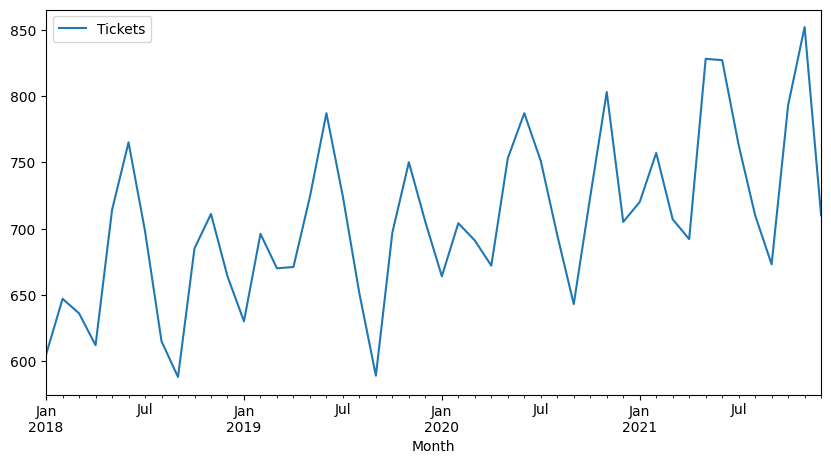

In [3]:
#1) Plot & analyse
data.plot(y='Tickets', figsize=[10,5])
# Trend + season = triple exponential smoothing

In [17]:
# Les oplossing | Train the model
train = data['Tickets'][:'2020-12-01']
test = data['Tickets']['2021-01-01':]

from statsmodels.tsa.holtwinters import ExponentialSmoothing

data_tes = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    freq='MS'
).fit()

des_fcast = data_tes.forecast(12)
des_fcast.head()

,0
2021-01-01,687.333374
2021-02-01,736.666678
2021-03-01,720.000051
2021-04-01,705.999975
2021-05-01,784.666791


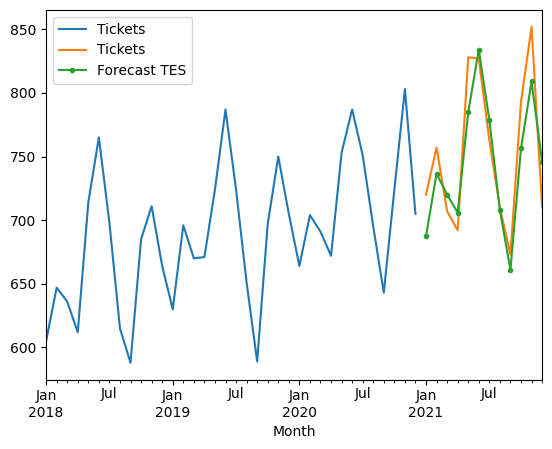

In [18]:
#Plot predicted values
train.plot(legend=True) #blauw
test.plot(legend=True) #oranje

des_fcast.plot(
    marker='.',
    legend=True,
    label='Forecast TES' #groen
);

In [20]:
# MAE berekenen
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test.values
y_predicted = des_fcast.values

mean_absolute_error(y_true, y_predicted)

22.944406940644672

## Source
Business Analytics Data Analysis & Decision Making